# Loading code base and Setup

In [40]:
include("../src/header/includes.jl");

  Activating project at `~/OneDrive/HHGsimPL.jl`


In [38]:
include("plotting-functions.jl");

In [ ]:
plotlyjs()

These are parameters that we don't usually change, hence they're marked as `const`.

In [16]:
const Ip = IpAU(15.7596) # Argon gas target
const λ = 800 #wavelength in nm
r = 1 # ω
s = 2 # 2*ω
const ε = 0.0 # linearly polarised field
const Intensity1 = 1.5e14;

# First test: Finding saddle points

For a given field configuration (`beam`), and a given harmonic order:

In [12]:
let 
    q = 25
    
    beam = BeamBEOTC(Intensity1 = Intensity1, 
        Intensity2 = 0.01*Intensity1,
        lambda = λ, r=1, s=2, epsilon = ε,
        phi=0.)
    
    ti_domain = ComplexDomain(-1.,0,0.05,0.35)*TCycle(beam);
    tr_domain = ComplexDomain(-0.6,0.25,-0.35,0.35)*TCycle(beam);
    saddles = find_saddles_sobol(q, b=beam, Ip = Ip, ti_cd = ti_domain, tr_cd = tr_domain, N = 150)       
end

3-element Vector{Saddle}:
 ti: -74.19 + 17.28im, tr: -19.81 - 1.6im, q25.0
 ti: -69.29 + 20.67im, tr: -54.03 - 25.73im, q25.0
 ti: -14.11 + 20.67im, tr: 1.14 - 25.73im, q25.0

For a given field configuration, plotting all saddle points in the complex plane is helpful:

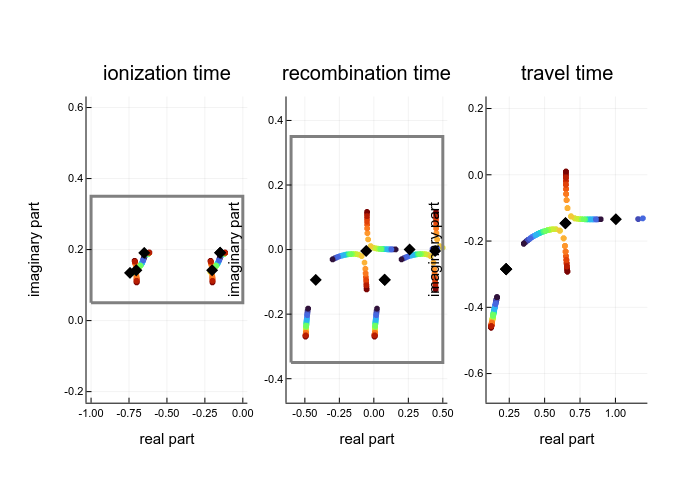

In [32]:
let
    beam = BeamBEOTC(Intensity1 = Intensity1, 
        Intensity2 = 0.01*Intensity1,
        lambda = λ, r=1, s=2, epsilon = ε,
        phi = 0.)
    
    # these windows are drawn as grey boundaries, just to be aware where one cuts off
    ti_domain = ComplexDomain(-1.,0, 0.05,0.35)*TCycle(beam); # (real(min), real(max), imag(min), imag(max))
    tr_domain = ComplexDomain(-0.6,0.5, -0.35,0.35)*TCycle(beam);    
    
    all_saddles = Dict{Number,Vector{Saddle}}()
    for q in range(15, stop = 40, step = 1)
        all_saddles[q] = find_saddles_sobol(q, b=beam, Ip = Ip, ti_cd = ti_domain, tr_cd = tr_domain, N = 150)    
    end
    
    # these are the fold points
    thcs = find_thcs_sobol(beam, Ip, ti_domain, tr_domain, N = 100)
    # it's not unreasonable to filter for fold points for which the coalescence happens at a harmonic order (q) that lies somewhat within our typical range
#     filter!(x -> (0 < real(x.qhc) < 45) && (real(x.trhc-x.tihc) < TCycle(beam)), thcs)
    
    
    plot_sp_times_cp(beam, all_saddles, thcs, ti_domain, tr_domain)    
    
end

# Calculating the necklace for a given saddle point

testsaddle = ti: -89.75 + 25.87im, tr: -20.97 - 9.66im, q20.0
I broke because the flow stopped after 367 iterations
it contributes!


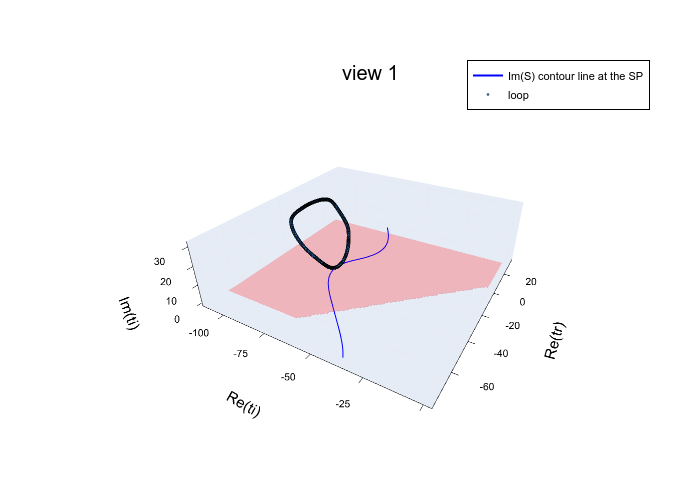

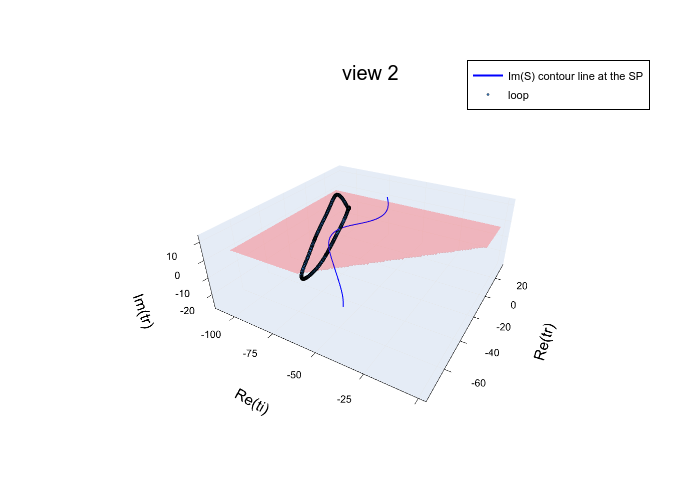

In [48]:
let 
    beam = BeamBEOTC(Intensity1=Intensity1, Intensity2=0.2*Intensity1,
        lambda = λ, r=1, s=2, epsilon = ε, phi=0.)
    q=20. # taking e.g. 35 here will yield a saddle point that doesn't contribute
    
    ti_domain = ComplexDomain(-1.,0,0.05,0.35)*TCycle(beam);
    tr_domain = ComplexDomain(-0.6,0.25,-0.35,0.35)*TCycle(beam);
    
    saddles = find_saddles_sobol(q, b=beam, Ip = Ip, ti_cd = ti_domain, tr_cd = tr_domain, N = 150)
    i = 2
    testsaddle = saddles[i]
    @show testsaddle
    
#     @time begin
    necklace = get_necklace(beam, Ip, q, testsaddle.ti, testsaddle.tr)
    check_contribution(necklace, beam, Ip, q, testsaddle.ti, testsaddle.tr, ti_domain, tr_domain) 
#     end
    
    # (because the contour line isn't necessarily calculated and hence not returned, so we need to calculate it again if we want to plot it)
    contourline =  contourline_through_saddle(beam, Ip, q, testsaddle.ti, testsaddle.tr, ti_domain, tr_domain )
    plot_necklace_3D(necklace, q, ti_domain, tr_domain, contourline)
    
end

# Problem case

the following necklace is wrong!

testsaddle = ti: -80.66 + 14.78im, tr: 8.82 + 0.15im, q23.0
I broke because the flow stopped after 155 iterations
it doesn't contribute! (1)


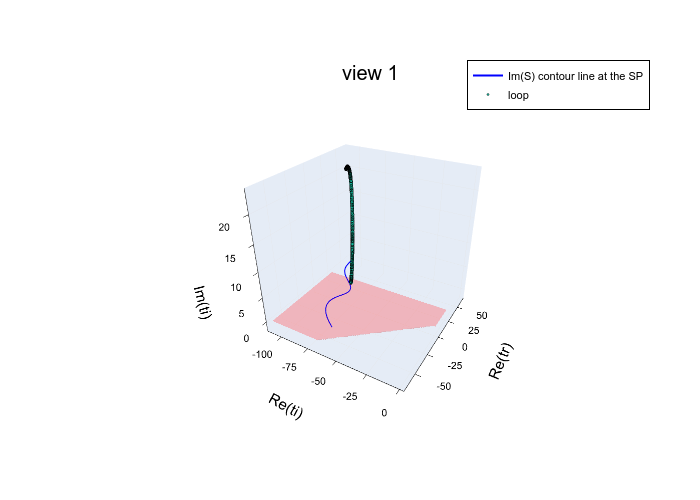

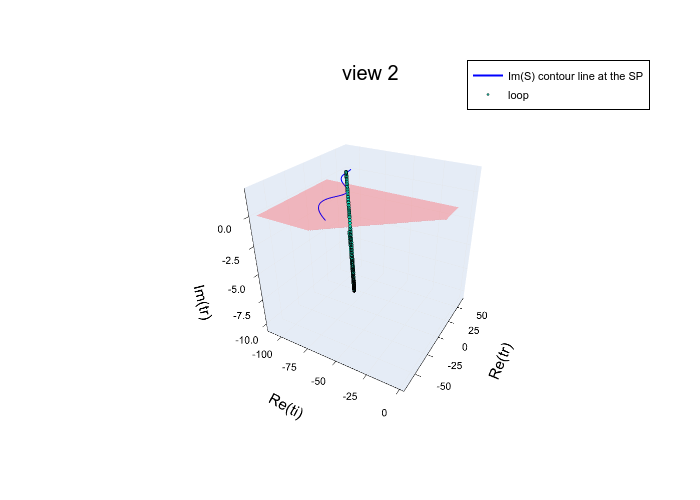

In [49]:
let 
    beam = BeamBEOTC(Intensity1=Intensity1, Intensity2=0.01*Intensity1,
        lambda = λ, r=1, s=2, epsilon = ε, phi = 2.0)
    q = 23.
    
    ti_domain = ComplexDomain(-1.,0,0.05,0.35)*TCycle(beam);
    tr_domain = ComplexDomain(-0.6,0.25,-0.35,0.35)*TCycle(beam);
    
    saddles = find_saddles_sobol(q, b=beam, Ip = Ip, ti_cd = ti_domain, tr_cd = tr_domain, N = 150)
    i = 1
    testsaddle = saddles[i]
    @show testsaddle
    
    necklace = get_necklace(beam, Ip, q, testsaddle.ti, testsaddle.tr)
    check_contribution(necklace, beam, Ip, q, testsaddle.ti, testsaddle.tr, ti_domain, tr_domain) 
    
    contourline = contourline_through_saddle(beam, Ip, q, testsaddle.ti, testsaddle.tr, ti_domain,tr_domain)
    plot_necklace_3D(necklace, q, ti_domain, tr_domain, contourline)
    
end

Let's look at it in the `(Im(ti), Im(tr))` and `(Re(ti), Re(tr))` plane:

testsaddle = ti: -80.66 + 14.78im, tr: 8.82 + 0.15im, q23.0
I broke because the flow stopped after 155 iterations


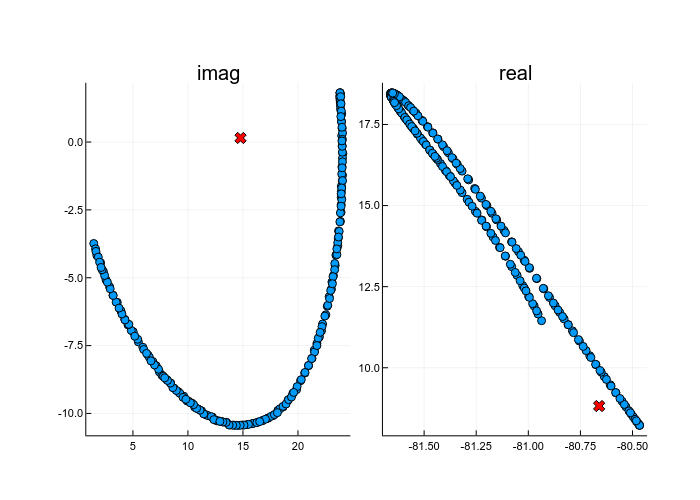

In [56]:
let
    beam = BeamBEOTC(Intensity1=Intensity1, Intensity2=0.01*Intensity1,
        lambda = λ, r=1, s=2, epsilon = ε, phi = 2.0)
    q = 23.
    
    ti_domain = ComplexDomain(-1.,0,0.05,0.35)*TCycle(beam);
    tr_domain = ComplexDomain(-0.6,0.25,-0.35,0.35)*TCycle(beam);
    
    saddles = find_saddles_sobol(q, b=beam, Ip = Ip, ti_cd = ti_domain, tr_cd = tr_domain, N = 150)
    i = 1
    testsaddle = saddles[i]
    @show testsaddle
    
    necklace = get_necklace(beam, Ip, q, testsaddle.ti, testsaddle.tr)
    
    plt_imag = scatter([imag.((necklace[n].s.x, necklace[n].s.y)) for n in 1:length(necklace)],
        title = "imag")
    scatter!(plt_imag, [imag.((testsaddle.ti,testsaddle.tr))], marker = (:red, :x, 5))
    
    plt_real = scatter([real.((necklace[n].s.x, necklace[n].s.y)) for n in 1:length(necklace)],
        title = "real")
    scatter!(plt_real, [real.((testsaddle.ti,testsaddle.tr))], marker = (:red, :x, 5))
    
    plot(plt_imag, plt_real, layout = (1,2), size = (800,400), legend = false 
    ) 
end

Let's see what goes wrong in the very first steps of the necklace calculation.

For this case it goes wrong:

testsaddle = ti: -80.66 + 14.78im, tr: 8.82 + 0.15im, q23.0
I broke because the counter reached its max, i.e. 1
I broke because the counter reached its max, i.e. 2
I broke because the counter reached its max, i.e. 3
I broke because the counter reached its max, i.e. 4
I broke because the counter reached its max, i.e. 6


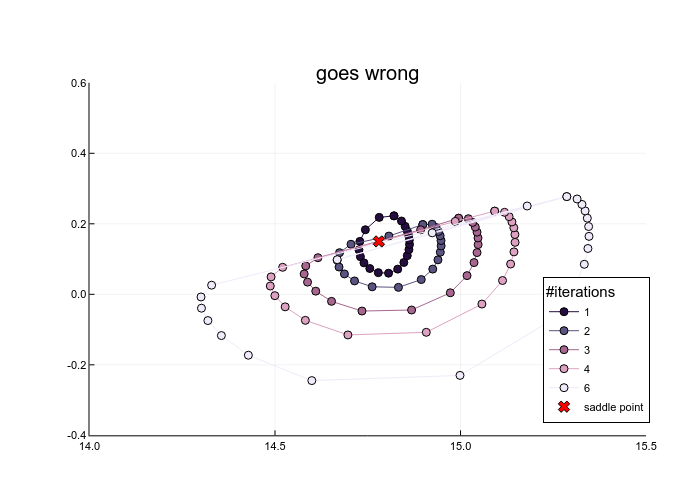

In [62]:
let
    beam = BeamBEOTC(Intensity1=Intensity1, Intensity2=0.01*Intensity1,
        lambda = λ, r=1, s=2, epsilon = ε, phi = 2.0)
    q = 23.
    
    ti_domain = ComplexDomain(-1.,0,0.05,0.35)*TCycle(beam);
    tr_domain = ComplexDomain(-0.6,0.25,-0.35,0.35)*TCycle(beam);
    
    saddles = find_saddles_sobol(q, b=beam, Ip = Ip, ti_cd = ti_domain, tr_cd = tr_domain, N = 150)
    i = 1
    testsaddle = saddles[i]
    @show testsaddle
    
    plt = plot(title = "goes wrong")
    for (nidx,n) in enumerate([1,2,3,4,6])
        necklace = get_necklace(beam, Ip, q, testsaddle.ti, testsaddle.tr, Ncounter = n)    
        plot!([imag.((necklace[i].s.x, necklace[i].s.y)) for i in 1:length(necklace)], legend = false
            , color = palette(:acton,5)[nidx], marker = true
            , label = "$n"
        )
    end
    scatter!([imag.((testsaddle.ti,testsaddle.tr))], marker = (:red, :x, 5), label = "saddle point")

    plot!(legendtitle = "#iterations", legend = true, legendposition = :bottomright
        , xlims = (14,15.5), ylims = (-0.4,0.6)
    )
    
end

However, if we choose the `eigvecfactorinit` a little larger, e.g. setting it to `0.02` (default is `0.01`), then it works:

testsaddle = ti: -80.66 + 14.78im, tr: 8.82 + 0.15im, q23.0
I broke because the counter reached its max, i.e. 1
I broke because the counter reached its max, i.e. 2
I broke because the counter reached its max, i.e. 3
I broke because the counter reached its max, i.e. 4
I broke because the counter reached its max, i.e. 6


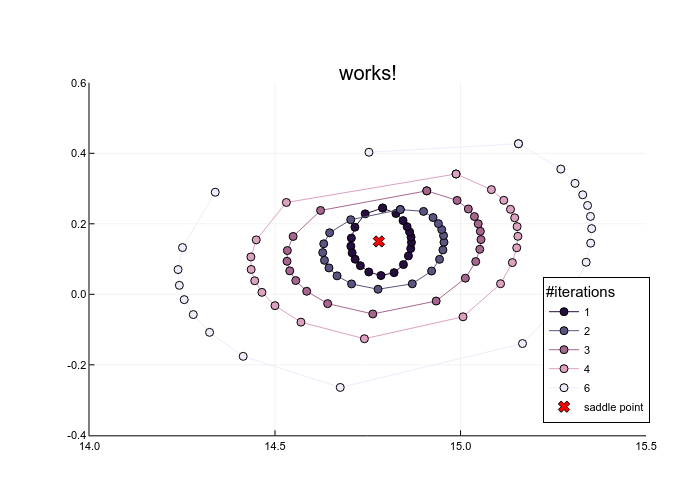

In [61]:
let
    beam = BeamBEOTC(Intensity1=Intensity1, Intensity2=0.01*Intensity1,
        lambda = λ, r=1, s=2, epsilon = ε, phi = 2.0)
    q = 23.
    
    ti_domain = ComplexDomain(-1.,0,0.05,0.35)*TCycle(beam);
    tr_domain = ComplexDomain(-0.6,0.25,-0.35,0.35)*TCycle(beam);
    
    saddles = find_saddles_sobol(q, b=beam, Ip = Ip, ti_cd = ti_domain, tr_cd = tr_domain, N = 150)
    i = 1
    testsaddle = saddles[i]
    @show testsaddle
    
    plt = plot(title = "works!")
    for (nidx,n) in enumerate([1,2,3,4,6])
        necklace = get_necklace(beam, Ip, q, testsaddle.ti, testsaddle.tr,
            Ncounter = n, eigvecfactorinit = 0.02)
        plot!([imag.((necklace[i].s.x, necklace[i].s.y)) for i in 1:length(necklace)], legend = false
            , color = palette(:acton,5)[nidx], marker = true
            , label = "$n"
        )
    end
    scatter!([imag.((testsaddle.ti,testsaddle.tr))], marker = (:red, :x, 5), label = "saddle point")

    plot!(legendtitle = "#iterations", legend = true, legendposition = :bottomright
        , xlims = (14,15.5), ylims = (-0.4,0.6)
    )
    
end